### **Autor:** David Roca Tauste

---
---
# **📌ACTIVIDAD 2: ENTRENAR NUESTRO MODELO**
---
---

In [60]:
import itertools
import os
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from hmmlearn import hmm
from scipy.io import wavfile
from python_speech_features import mfcc, logfbank, delta

# import librosa                    # Otra posibilidad de leer audio: audio, fm = librosa.load(fichero_audio)
# from librosa.feature import mfcc  # Otra posibilidad de extraer escalas mel del audio
import matplotlib.pyplot as plt
import pickle
import warnings

#warnings.filterwarnings("ignore")

In [61]:
##########======== PARÁMETROS PARA DEFINIR EL DATASET =========##########
carpeta = "../Audios/"
n_caracteristicas = 10  # Num. de características mel de cada trozo de audio
tama_caracteristicas = 10  # Cantidad de datos de cada característica
valor_imputado = 0.1  # Mecanismo de seguridad para no alimentar HMM con valores NaN
mucha_informacion = True  # Mostrar progreso de cada acción paso a paso
ratio_de_train = 0.1  # Porcentaje de ejemplos para train ente 0.0 y 1.0

##########======== HIPERPARÁMETROS DE LOS MODELOS: =========##########
# Hay dos posibles modelos:
# - hmm.GMMHMM()        Gaussiano Mixture con HMM. La emisión de un símbolo se modela como una
#                       distribución aleatoria que es una mezcla de otras distribuciones.
# - hmm.GaussianHMM()   Gaussiano con HMM. La emisión obedece a una única distribución.
# Aunque tienen más, solamente usaremos estos:
n_estados_ocultos = 1  # Estados ocultos usados en el HMM
n_iteraciones = 10  # Iteraciones en el algoritmo (viterbi por defecto)
##########=================================================##########

In [62]:
def extraer_caracteristicas(ruta_audio):
    # audio, frec_muestreo = librosa.load(ruta_audio)
    # mfcc_carac = mfcc(y=audio, sr=frec_muestreo, n_mfcc=n_caracteristicas)
    frec_muestreo, audio = wavfile.read(ruta_audio)
    mfcc_carac = mfcc(
        audio,
        frec_muestreo,
        nfft=2048,
        numcep=n_caracteristicas,
        nfilt=tama_caracteristicas,
    )
    if mucha_informacion:
        print(f"{ruta_audio} Dimensiones de mfcc {mfcc_carac.shape}")
    return mfcc_carac

In [63]:
def definir_dataset(ruta_audios=carpeta):
    ficheros = sorted(os.listdir(ruta_audios))
    x_train = []
    y_train = []
    x_test = []
    y_test = []
    datos = dict()
    n = len(ficheros)
    digito_actual = ""
    for i in range(n):
        if not ficheros[i].lower().endswith(".wav"):
            continue
        digito = ficheros[i][0]  # digito-nombre.wav
        if mucha_informacion and digito_actual != digito:
            digito_actual = digito
            print("Procesando ficheros del dígito " + digito + ">")
        carac = extraer_caracteristicas(ruta_audio=ruta_audios + ficheros[i])
        if digito not in datos.keys():
            datos[digito] = [carac]
            x_train.append(carac)
            y_train.append(digito)
        else:
            if np.random.rand() < ratio_de_train:  # Añadirlo a train o a test
                x_test.append(carac)
                y_test.append(digito)
            else:
                datos[digito].append(carac)
                x_train.append(carac)
                y_train.append(digito)
    return x_train, y_train, x_test, y_test, datos

In [64]:
def entrenar_modelo(datos):
    hmm_aprendido = dict()
    for label in datos.keys():
        # modelo = hmm.GaussianHMM(n_components=n_estados_ocultos, n_iter=n_iteraciones)
        modelo = hmm.GaussianHMM(
            n_components=n_estados_ocultos,
            n_iter=n_iteraciones,
            verbose=mucha_informacion,
        )
        caracteristica = None
        for cada_caracteristica in datos[label]:
            cada_caracteristica = np.nan_to_num(cada_caracteristica, nan=valor_imputado)
            if caracteristica is None:
                caracteristica = cada_caracteristica
            else:
                caracteristica = np.vstack((caracteristica, cada_caracteristica))
        obj = modelo.fit(caracteristica)
        if mucha_informacion:
            print("***** Modelo de", label)
            print("Prob. de inicio:", obj.startprob_)
            print("Matriz de transición:\n", obj.transmat_)
        hmm_aprendido[label] = obj
    return hmm_aprendido

In [65]:
def hacer_prediccion(datos_test, entrenado):
    label_predicha = []  # predecir una lista de test
    nombres = []
    if type(datos_test) == type([]):
        for test in datos_test:
            scores = []
            for nodo in entrenado.keys():
                scores.append(entrenado[nodo].score(test))
                nombres.append(nodo)
            label_predicha.append(scores.index(max(scores)))
    else:
        scores = []
        for nodo in entrenado.keys():
            scores.append(entrenado[nodo].score(datos_test))
            nombres.append(nodo)
        label_predicha.append(scores.index(max(scores)))
    return nombres[label_predicha[0]]

In [66]:
def plot_matriz_confusion(
    cm, clases, normaliza=False, titulo="Matriz de Confusión", cmap=plt.cm.Blues
):
    plt.imshow(cm, interpolation="nearest", cmap=cmap)
    plt.title(titulo)
    plt.colorbar()
    tick_marks = np.arange(len(clases))
    plt.xticks(tick_marks, clases, rotation=45)
    plt.yticks(tick_marks, clases)

    fmt = ".2f" if normaliza else "d"
    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(
            j,
            i,
            format(cm[i, j], fmt),
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black",
        )

    plt.tight_layout()
    plt.ylabel("Label real")
    plt.xlabel("Label predicha")
    plt.show()

In [67]:
def informe(y_test, y_pred, mostrar_grafico=True):
    print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
    print("-" * 60)
    print("Informe de clasificación:\n\n", classification_report(y_test, y_pred))
    print("-" * 60)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("-" * 60 + "\n")
    if mostrar_grafico:
        plot_matriz_confusion(
            confusion_matrix(y_test, y_pred), [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
        )

---

In [68]:
# PASO 1: Definir el dataset
# ==========================
x_train, y_train, x_test, y_test, datos = definir_dataset()
print("Datos de entrenamiento: ", len(x_train))
print("Datos de test: ", len(x_test))
print("Diccionario de datos contiene datos de:", datos.keys())

Procesando ficheros del dígito 0>
../Audios/0-DAVROCTAU-0.wav Dimensiones de mfcc (332, 10)
../Audios/0-DAVROCTAU-1.wav Dimensiones de mfcc (340, 10)
Procesando ficheros del dígito 1>
../Audios/1-DAVROCTAU-0.wav Dimensiones de mfcc (336, 10)
../Audios/1-DAVROCTAU-1.wav Dimensiones de mfcc (353, 10)
Procesando ficheros del dígito 2>
../Audios/2-DAVROCTAU-0.wav Dimensiones de mfcc (383, 10)
../Audios/2-DAVROCTAU-1.wav Dimensiones de mfcc (370, 10)
Procesando ficheros del dígito 3>
../Audios/3-DAVROCTAU-0.wav Dimensiones de mfcc (298, 10)
../Audios/3-DAVROCTAU-1.wav Dimensiones de mfcc (349, 10)
Procesando ficheros del dígito 4>
../Audios/4-DAVROCTAU-0.wav Dimensiones de mfcc (319, 10)
../Audios/4-DAVROCTAU-1.wav Dimensiones de mfcc (357, 10)
Procesando ficheros del dígito 5>
../Audios/5-DAVROCTAU-0.wav Dimensiones de mfcc (264, 10)
../Audios/5-DAVROCTAU-1.wav Dimensiones de mfcc (319, 10)
Procesando ficheros del dígito 6>
../Audios/6-DAVROCTAU-0.wav Dimensiones de mfcc (379, 10)
../Audio

In [69]:
# PASO 2: Entrenar el modelo
# ==========================
hmm = entrenar_modelo(datos)

# Guardar modelo
with open("modelo_aprendido.pkl", "wb") as fichero:
    pickle.dump(hmm, fichero)
print("Entrenamiento realizado...")

         1  -20985.96778118             +nan
         2  -20985.96387128      +0.00390990
         1  -21633.83741123             +nan
         2  -21633.83357486      +0.00383637
         1  -24955.38798328             +nan
         2  -24955.38451379      +0.00346949


***** Modelo de 0
Prob. de inicio: [1.]
Matriz de transición:
 [[1.]]
***** Modelo de 1
Prob. de inicio: [1.]
Matriz de transición:
 [[1.]]
***** Modelo de 2
Prob. de inicio: [1.]
Matriz de transición:
 [[1.]]


         1  -21173.27873145             +nan
         2  -21173.27470682      +0.00402463
         1  -21620.97367034             +nan
         2  -21620.96977429      +0.00389605
         1  -19451.16215206             +nan
         2  -19451.15769429      +0.00445778


***** Modelo de 3
Prob. de inicio: [1.]
Matriz de transición:
 [[1.]]
***** Modelo de 4
Prob. de inicio: [1.]
Matriz de transición:
 [[1.]]
***** Modelo de 5
Prob. de inicio: [1.]
Matriz de transición:
 [[1.]]


         1  -24442.82541303             +nan
         2  -24442.82178980      +0.00362324
         1  -32193.80244608             +nan
         2  -32193.79982248      +0.00262361
         1  -11064.86706291             +nan
         2  -11064.85962721      +0.00743570


***** Modelo de 6
Prob. de inicio: [1.]
Matriz de transición:
 [[1.]]
***** Modelo de 7
Prob. de inicio: [1.]
Matriz de transición:
 [[1.]]
***** Modelo de 8
Prob. de inicio: [1.]
Matriz de transición:
 [[1.]]
***** Modelo de 9
Prob. de inicio: [1.]
Matriz de transición:
 [[1.]]
Entrenamiento realizado...


         1  -22239.55558256             +nan
         2  -22239.55193799      +0.00364458


Matriz de confusión:
 [[2 0 0 0 0 0 0 0 0 0]
 [0 2 0 0 0 0 0 0 0 0]
 [0 0 2 0 0 0 0 0 0 0]
 [0 0 0 2 0 0 0 0 0 0]
 [0 0 0 0 2 0 0 0 0 0]
 [0 0 0 0 0 2 0 0 0 0]
 [0 0 0 0 0 0 2 0 0 0]
 [0 0 1 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 2]]
------------------------------------------------------------
Informe de clasificación:

               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2
           2       0.67      1.00      0.80         2
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         2
           7       1.00      0.50      0.67         2
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         2

    accuracy                           0.95        19
   macro

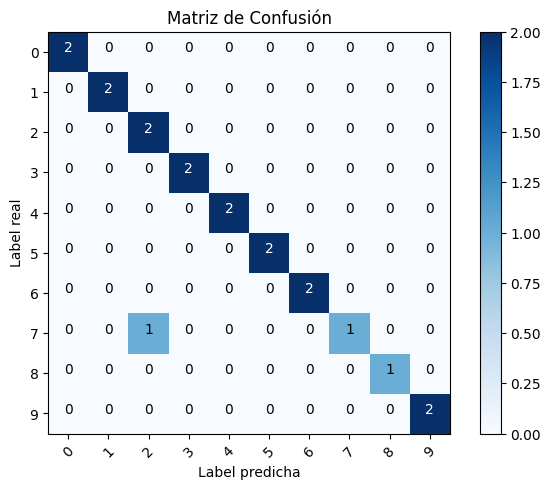

Matriz de confusión:
 [[1]]
------------------------------------------------------------
Informe de clasificación:

               precision    recall  f1-score   support

           8       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1

------------------------------------------------------------
Accuracy: 1.0
------------------------------------------------------------



c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:409: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:409: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


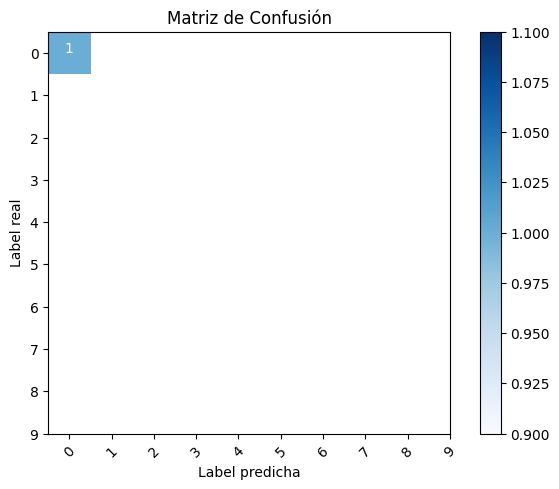

############################################################ TRAIN ACCURACY ############################################################
0.9473684210526315
 
############################################################ TEST ACCURACY ############################################################
1.0


In [70]:
# PASO 3: Usar el modelo para predecir
# ==================================
# Leer modelo de disco si queremos usarlo tras crearlo
with open("modelo_aprendido.pkl", "rb") as fichero:
    hmm = pickle.load(fichero)

ficheros = sorted(os.listdir(carpeta))
tot_test = 0
tot_train = 0
n = len(x_test)
m = len(x_train)
pred_test = []
pred_train = []
for i in range(m):
    y_pred = hacer_prediccion(x_train[i], hmm)
    if y_pred == y_train[i]:
        tot_train += 1
    pred_train.append(y_pred)

for i in range(n):
    y_pred = hacer_prediccion(x_test[i], hmm)
    if y_pred == y_test[i]:
        tot_test += 1
    pred_test.append(y_pred)

informe(y_train, pred_train)
informe(y_test, pred_test)

print("#" * 60 + " TRAIN ACCURACY " + "#" * 60)
print(tot_train / m)
print(" ")
print("#" * 60 + " TEST ACCURACY " + "#" * 60)
print(tot_test / n)

---

## ENTREGA 4: Entrega:
### a) El código del programa Python.
Se encuentra arriba.

### b) Captura de pantalla del resultado de una ejecución.
Se encuentra arriba.